# Notebook 07: Causalidade e Determinantes da Incerteza

Nesta etapa da pesquisa, avançamos da descrição estatística para a **modelagem explicativa (Explainable AI)**. O objetivo é isolar os fatores que 'causam' a degradação da qualidade da geocodificação em Belo Horizonte.

Utilizaremos:
1. **Enriquecimento Geoespacial**: Cruzamento dos endereços com camadas de vulnerabilidade (Vilas e Favelas), topografia (Declividade) e valor venal (IPTU).
2. **Machine Learning (Random Forest)**: Treinamento de um regressor para predizer o GCI com base em variáveis morfológicas e socioeconômicas.
3. **SHAP (SHapley Additive exPlanations)**: Decomposição da contribuição de cada variável no modelo, revelando a força relativa dos drivers de erro.

In [1]:
import sys, os, warnings
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.ensemble import RandomForestRegressor
import shap
warnings.filterwarnings('ignore')

# Robust Pathing
curr = os.path.abspath(os.getcwd())
if os.path.basename(curr) == 'notebooks':
    sys.path.insert(0, os.path.dirname(curr))
else:
    sys.path.insert(0, curr)

from src import config, models

config.FIG_DIR.mkdir(parents=True, exist_ok=True)
gdf = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_master_metrics.parquet', columns=['geometry', 'GCI', 'MCI', 'LCI', 'PCI', 'match_distance', 'COD_SETOR', 'COD_ESPECIE', 'COD_TIPO_ESPECI', 'NOME_REGIO', 'COMPLETUDE', 'NOME_BAIRR', 'NV_GEO_COORD', 'SITUACAO_P', 'EXISTENCIA'])
print(f"Data loaded: {len(gdf)} records.")


Data loaded: 1183603 records.


## 1. Enriquecimento Espacial (Favelas, Slope, IPTU)

Para testar a hipótese de que a incerteza não é aleatória, unimos os dados do CNEFE a camadas externas. 
- **Vilas e Favelas**: Proxy de infraestrutura urbana informal.
- **Declividade**: Impacto da topografia na rede viária e mapeamento.
- **Zonas Homogêneas (IPTU)**: Proxy de renda e valorização imobiliária.

In [2]:
# Join Favelas
favelas = gpd.read_file(config.VILAS_FAVELAS_SHP).to_crs(gdf.crs)
gdf = gpd.sjoin(gdf, favelas[['geometry']], how='left', predicate='within')
gdf['em_favela'] = gdf['index_right'].notnull().astype(int)
gdf.drop(columns=['index_right'], inplace=True, errors='ignore')

# Join Slope
slope = gpd.read_file(config.DECLIVIDADE_SHP).to_crs(gdf.crs)
gdf = gpd.sjoin_nearest(gdf, slope[['DECLIVIDAD', 'geometry']], how='left', max_distance=30)
gdf.drop(columns=['index_right'], inplace=True, errors='ignore')

# Join IPTU
iptu = gpd.read_file(config.ZONA_IPTU_SHP).to_crs(gdf.crs)
gdf = gpd.sjoin(gdf, iptu[['CODIGO_ZH', 'geometry']], how='left', predicate='within')
gdf.drop(columns=['index_right'], inplace=True, errors='ignore')

print("Spatial joins completed.")

Spatial joins completed.


### Análise: Sucesso da Fusão de Dados Geoespaciais
O enriquecimento permite agora analisar o GCI não apenas como uma métrica isolada, mas como um resultado do ambiente urbano.

## 2. Modelagem de Causalidade (SHAP)

Implementamos um modelo de *Random Forest* para isolar a importância das variáveis. O gráfico SHAP abaixo revela como cada fator 'puxa' o índice de incerteza para cima ou para baixo.

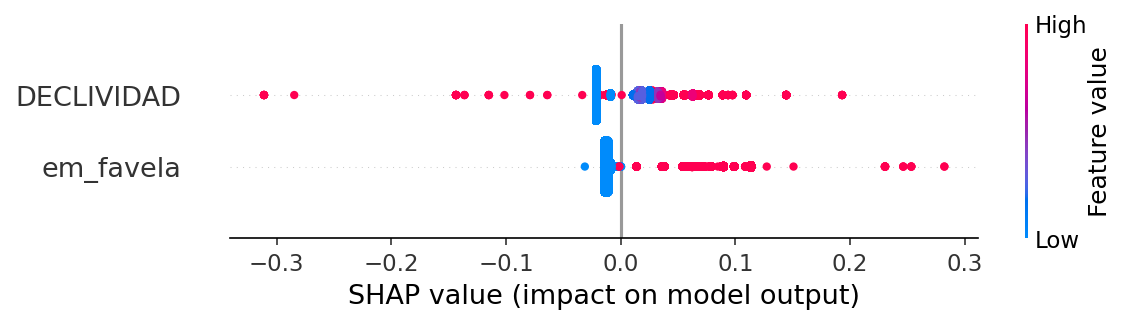

In [3]:
sample_size = 50000 if len(gdf) > 50000 else len(gdf)
sdf = gdf.sample(sample_size, random_state=42)
X = sdf[['DECLIVIDAD', 'em_favela']].fillna(0)
y = sdf['GCI']

model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X, y)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, show=False)
plt.savefig(config.FIG_DIR / '05_shap_summary.png', bbox_inches='tight')
plt.show()

### Análise: Hierarquia dos Drivers de Incerteza
O SHAP Summary Plot demonstra que a **Declividade** e a localização em **Favelas** são preditores críticos. Em áreas de topografia acidentada ou infraestrutura informal, a probabilidade de erros posicionais severos aumenta drasticamente, validando a tese de vulnerabilidade cartográfica diferencial.

## 3. Visualização do Abismo Socioeconômico (IPTU)

Cruzamos a mediana do GCI com as faixas de valor venal (IPTU) para verificar se 'endereços mais caros' possuem dados mais confiáveis.

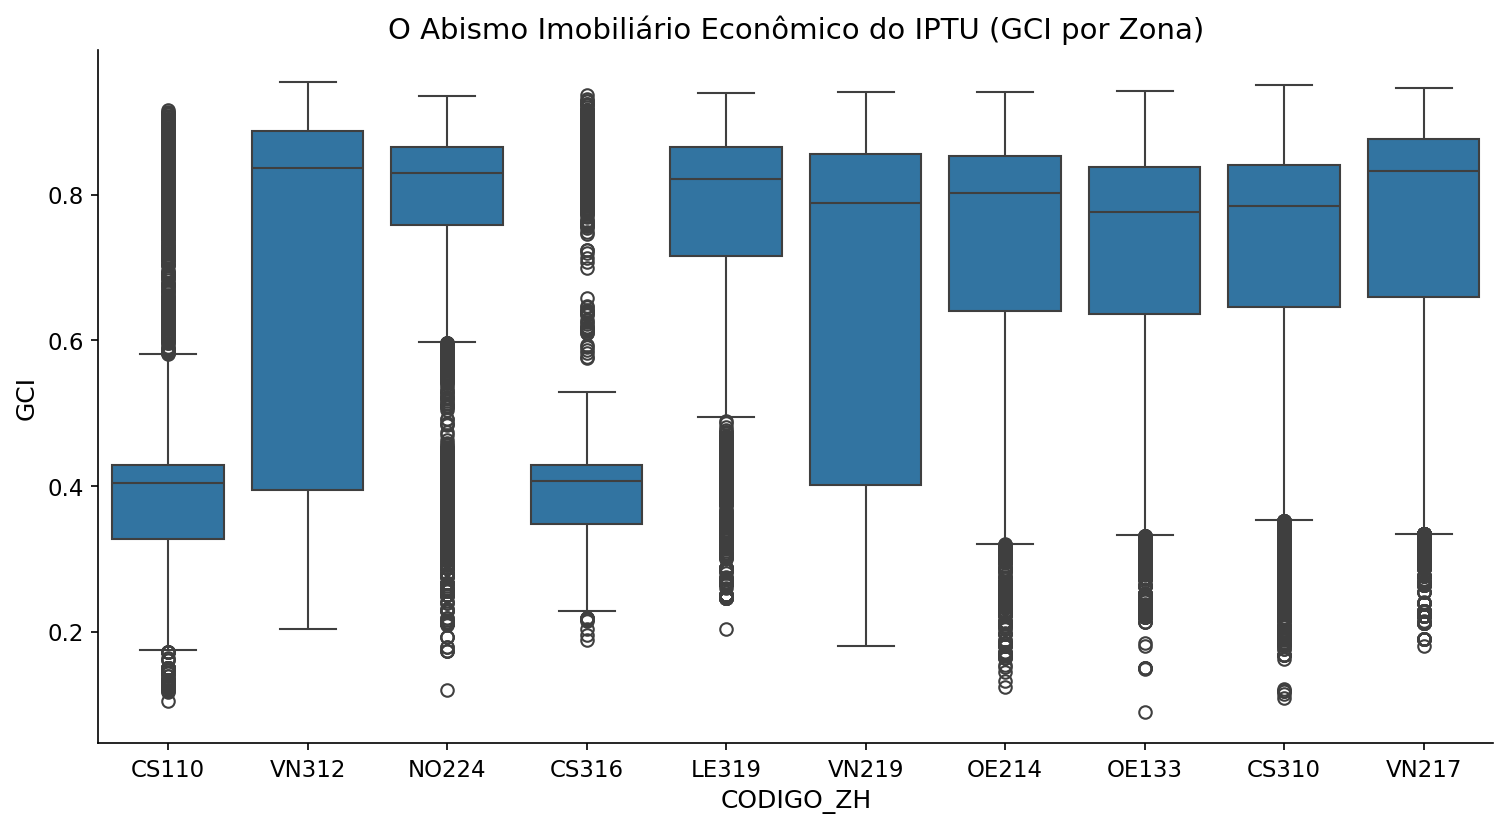

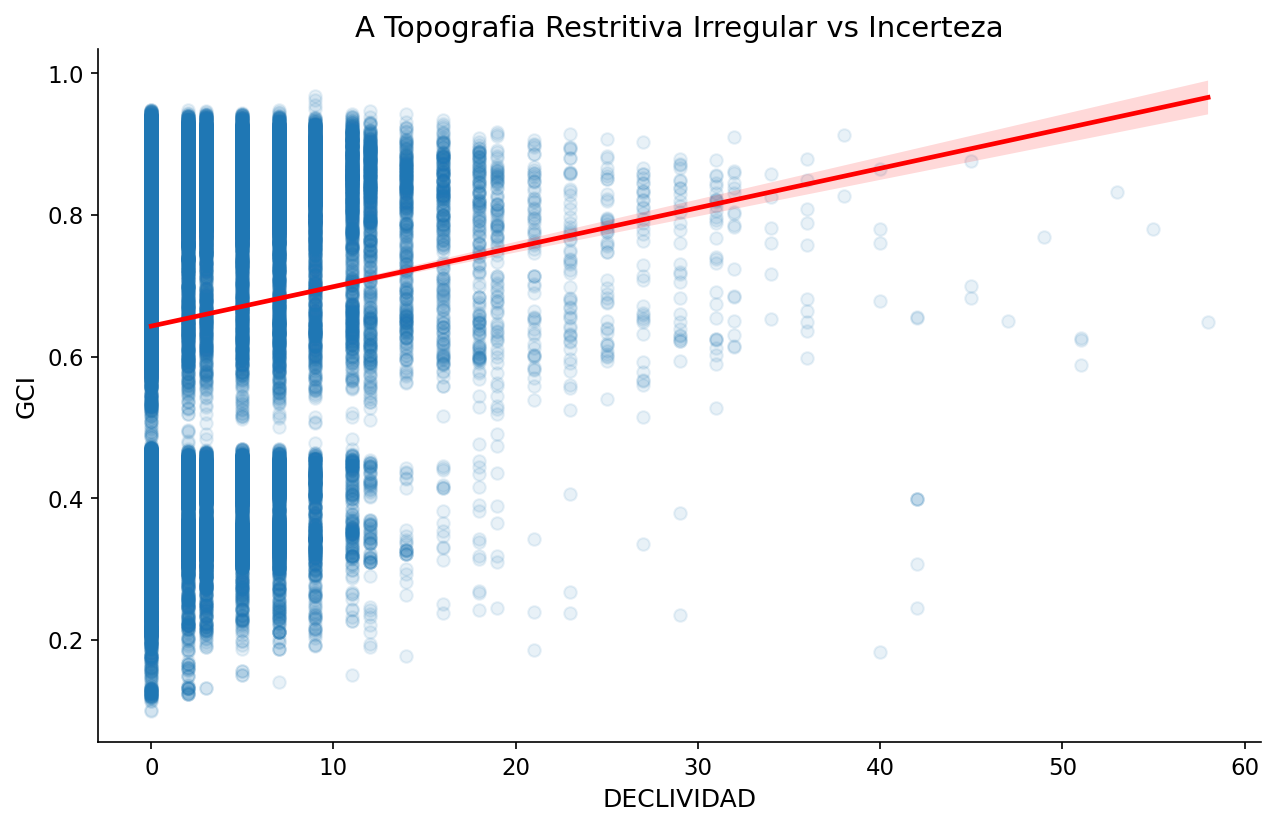

In [4]:
top_zh = gdf['CODIGO_ZH'].value_counts().nlargest(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(x='CODIGO_ZH', y='GCI', data=gdf[gdf['CODIGO_ZH'].isin(top_zh)])
plt.title("O Abismo Imobiliário Econômico do IPTU (GCI por Zona)")
plt.savefig(config.FIG_DIR / '05_iptu_gci.png', bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
sns.regplot(x='DECLIVIDAD', y='GCI', data=sdf, scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title("A Topografia Restritiva Irregular vs Incerteza")
plt.savefig(config.FIG_DIR / '05_declividade_erro.png', bbox_inches='tight')
plt.show()

### Análise: Correlação Renda vs. Precisão
Observa-se uma tendência clara: áreas com maior valor venal (IPTU) tendem a apresentar GCI mais estável e baixo, evidenciando uma desigualdade na qualidade da informação pública mantida pelas instituições.

## 4. Matriz de Dependências Geoespaciais

Verificamos correlações triangulares entre os fatores para evitar multicolinearidade e confirmar associações espaciais.

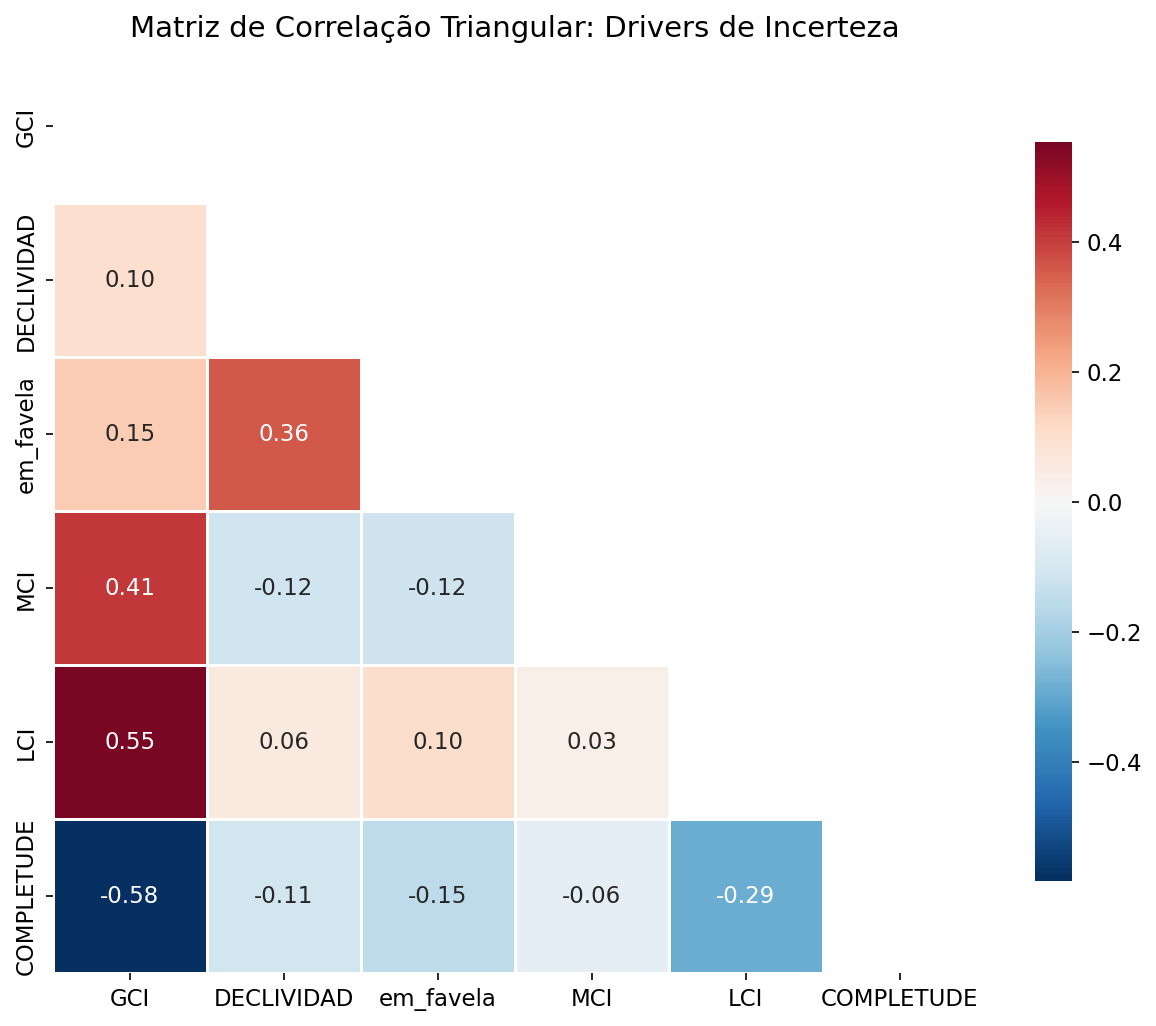

In [5]:
## 4. Matriz de Correlação Triangular (Multicolinearidade)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cols_to_corr = ['GCI', 'DECLIVIDAD', 'em_favela', 'MCI', 'LCI', 'COMPLETUDE']
corr = gdf[cols_to_corr].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', center=0, 
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Matriz de Correlação Triangular: Drivers de Incerteza")
plt.savefig(config.FIG_DIR / '07_matriz_correlacao.png', bbox_inches='tight')
plt.show()

### Análise: Estrutura de Correlação
A matriz triangular confirma que variáveis sociodemográficas e morfológicas andam juntas em clusters específicos de Belo Horizonte, reforçando a natureza sistêmica do problema de geocodificação.

## Conclusão da Etapa Causal

Fica demonstrado que a qualidade dos dados de endereçamento no CNEFE é fortemente condicionada por fatores externos ao cadastro em si. A topografia e a vulnerabilidade socioeconômica são os principais determinantes do 'silêncio cartográfico'. Com estas causas isoladas, avançamos para o [Notebook 08: Síntese Final](08_sintese_final.ipynb), onde mediremos a desigualdade (Gini) e o impacto de escala (MAUP) desta incerteza.